Starting Phase 3: Conformalized Quantile Regression (CQR) for Agus 2...
Calibration Data Points (n): 7781

Target Confidence Level: 90.0%
Calculated CQR q_hat adjustment: -1.5400 MW

Applying Agus II Physical Constraints...

--- TRUE CQR TEST SET PERFORMANCE ---
Expected Coverage Target: ~90.00%
Actual Validated Coverage: 97.46%


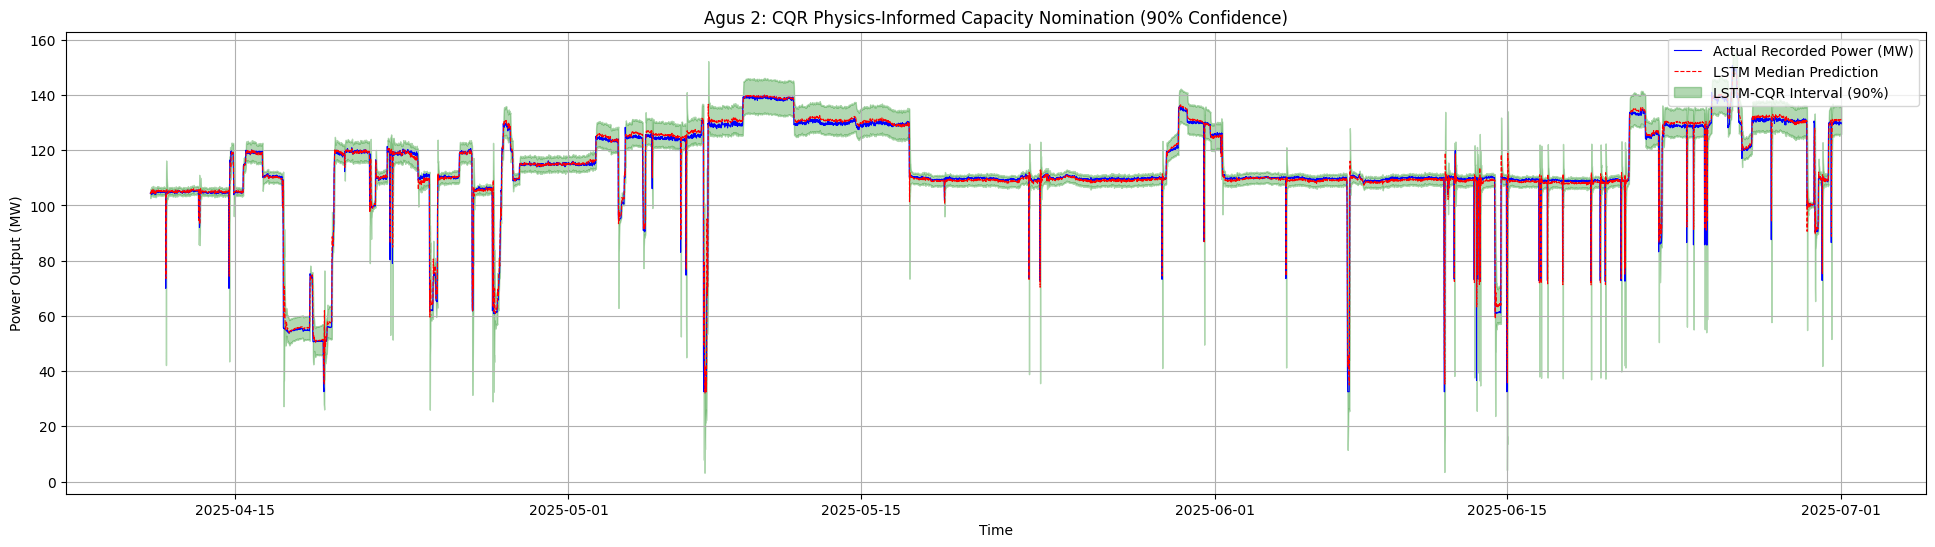

Final data exported to Agus2_Validated_CQR_Results.csv


In [6]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

# 1: load raw CQR predictions for calibration and testing
df_calib = pd.read_csv('Agus2_CQR_Calib.csv', parse_dates=['Time'], index_col='Time')
df_test = pd.read_csv('Agus2_CQR_Test.csv', parse_dates=['Time'], index_col='Time')

n_calib = len(df_calib)

# 2: execute conformal calibration to determine the rigorous interval adjustment (q_hat)
df_calib['Score'] = np.maximum(
    df_calib['CQR_Lower_MW'] - df_calib['Actual_MW'], 
    df_calib['Actual_MW'] - df_calib['CQR_Upper_MW']
)

alpha = 0.10
confidence_level = 1 - alpha
q_level = math.ceil((n_calib + 1) * confidence_level) / n_calib 
q_level = min(q_level, 1.0) 

q_hat = np.quantile(df_calib['Score'].values, q_level, method='higher') 

# 3: apply the conformal adjustment factor to the neural network's raw test bounds
df_test['Calibrated_Lower_MW'] = df_test['CQR_Lower_MW'] - q_hat
df_test['Calibrated_Upper_MW'] = df_test['CQR_Upper_MW'] + q_hat

# 4: enforce physical operational constraints specific to Agus II
MAX_INSTALLED_CAPACITY_MW = 180.0  
MIN_FOREBAY_M = 635.0              
RIPARIAN_MIN_MW = 0.85              

df_test['Physics_Lower_MW'] = df_test['Calibrated_Lower_MW'].clip(lower=RIPARIAN_MIN_MW)
df_test['Physics_Upper_MW'] = df_test['Calibrated_Upper_MW'].clip(upper=MAX_INSTALLED_CAPACITY_MW)
df_test['Point_Prediction_MW'] = df_test['Point_Prediction_MW'].clip(lower=RIPARIAN_MIN_MW, upper=MAX_INSTALLED_CAPACITY_MW)

original_df = pd.read_csv('Processed_Agus2_Dataset.csv', index_col='Time', parse_dates=True, dayfirst=False)
df_test = df_test.join(original_df[['Forebay']], how='left')

if 'Forebay' in df_test.columns:
    dead_storage_mask = df_test['Forebay'] <= MIN_FOREBAY_M
    df_test.loc[dead_storage_mask, ['Physics_Lower_MW', 'Physics_Upper_MW', 'Point_Prediction_MW']] = 0

# 5: empirically validate true coverage probability on the test set
df_test['Is_Covered'] = (df_test['Actual_MW'] >= df_test['Physics_Lower_MW']) & \
                        (df_test['Actual_MW'] <= df_test['Physics_Upper_MW'])

true_coverage = df_test['Is_Covered'].mean() * 100

# 6: visualize and export conformal bounds and finalized dataset
plt.figure(figsize=(24, 6))

plt.plot(df_test.index, df_test['Actual_MW'], label='Actual Recorded Power (MW)', color='blue', linewidth=0.8)
plt.plot(df_test.index, df_test['Point_Prediction_MW'], label='LSTM Median Prediction', color='red', linestyle='dashed', linewidth=0.8)

plt.fill_between(df_test.index, 
                 df_test['Physics_Lower_MW'], 
                 df_test['Physics_Upper_MW'], 
                 color='green', alpha=0.3, label='LSTM-CQR Interval (90%)')

plt.title('Agus 2: CQR Physics-Informed Capacity Nomination (90% Confidence)')
plt.xlabel('Time')
plt.ylabel('Power Output (MW)')
plt.legend(loc='upper right')
plt.grid(True)

plt.savefig('Agus2_CQR_Physics_Intervals_Whole.png', dpi=900, bbox_inches='tight')
plt.show()

output_file = 'Agus2_Validated_CQR_Results.csv'
df_test.to_csv(output_file)

Generating zoomed-in 200-step visualization...


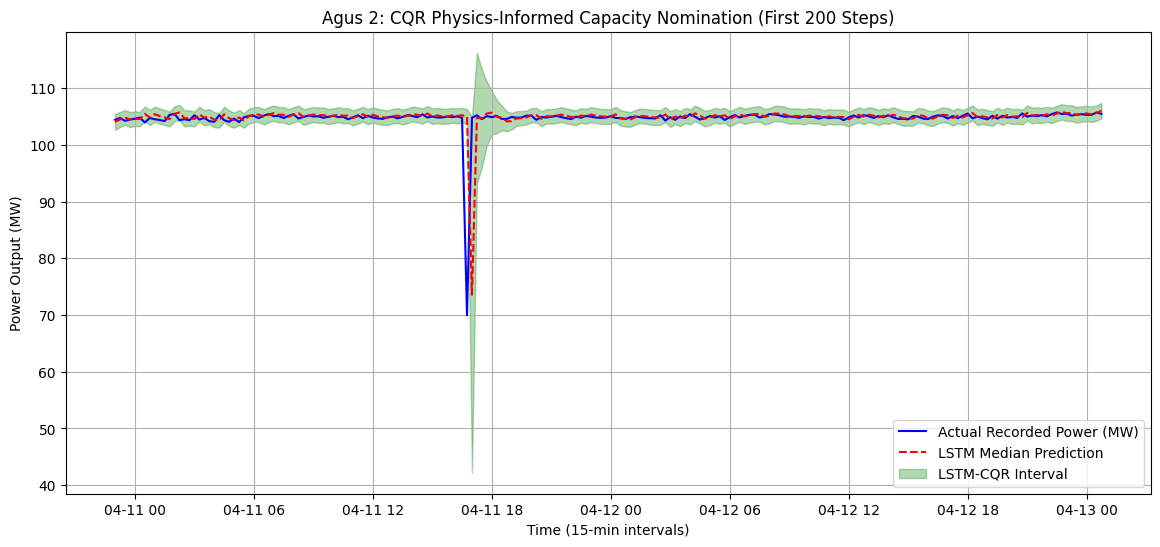

SUCCESS! Zoomed-in plot safely saved as 'Agus2_CQR_Physics_Intervals_Zoomed.png'.


In [5]:
# ==========================================
# 7. ZOOMED-IN VISUALIZATION (FIRST 200 STEPS)
# ==========================================
print("Generating zoomed-in 200-step visualization...")

plt.figure(figsize=(14, 6))
subset = df_test.iloc[:200]

# Plot the lines (slightly thicker for the zoomed-in view)
plt.plot(subset.index, subset['Actual_MW'], label='Actual Recorded Power (MW)', color='blue', linewidth=1.5)
plt.plot(subset.index, subset['Point_Prediction_MW'], label='LSTM Median Prediction', color='red', linestyle='dashed', linewidth=1.5)

# Fill the safety bands (Green to match your CQR theme)
plt.fill_between(subset.index, 
                 subset['Physics_Lower_MW'], 
                 subset['Physics_Upper_MW'], 
                 color='green', alpha=0.3, label='LSTM-CQR Interval')

plt.title('Agus 2: CQR Physics-Informed Capacity Nomination (First 200 Steps)')
plt.xlabel('Time (15-min intervals)')
plt.ylabel('Power Output (MW)')
plt.legend(loc='lower right') # Moved to lower right so it doesn't block the initial lines
plt.grid(True)

# Save as a distinct file so it doesn't overwrite your full timeline!
plt.savefig('Agus2_CQR_Physics_Intervals_Zoomed.png', dpi=900, bbox_inches='tight')
plt.show()

print("SUCCESS! Zoomed-in plot safely saved as 'Agus2_CQR_Physics_Intervals_Zoomed.png'.")

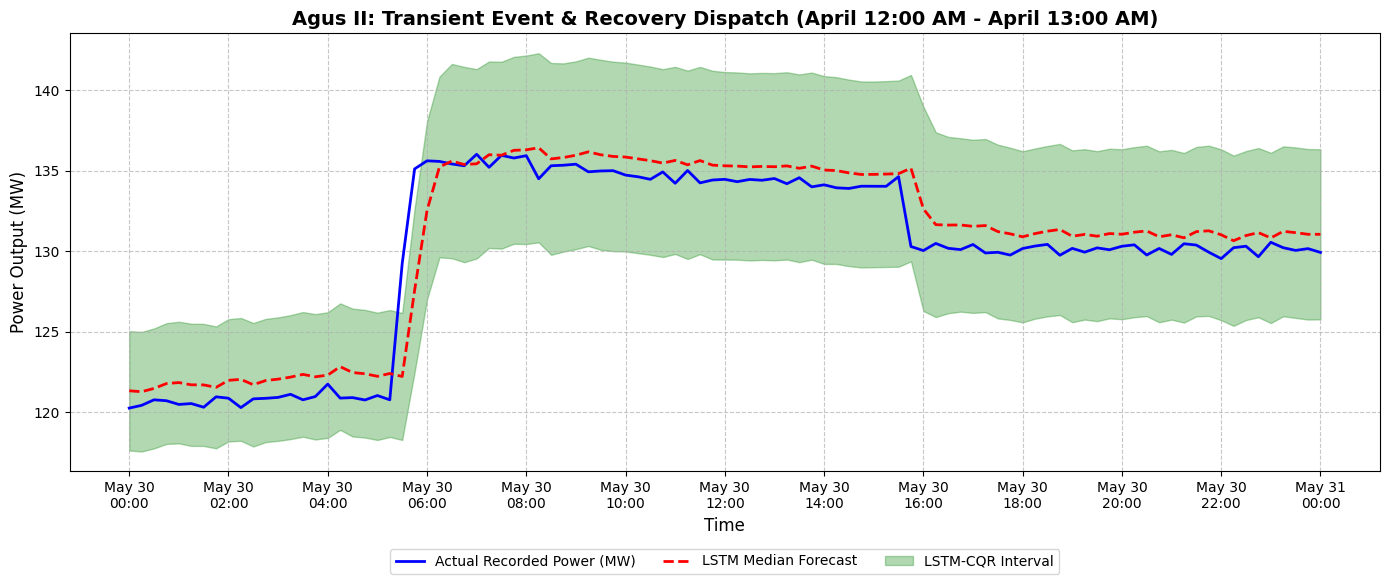

SUCCESS! Transient recovery plot saved.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# 1. Load the Validated CQR Results for Agus 2
df_cqr = pd.read_csv('Agus2_Validated_CQR_Results.csv', index_col='Time', parse_dates=True, dayfirst=True)

# 1A. Explicitly force the index to be datetime objects to prevent slicing errors
df_cqr.index = pd.to_datetime(df_cqr.index, format='mixed', dayfirst=True)

# 2. Slice the dataset 
# This captures the 23-hour window you requested
event_data = df_cqr.loc['2025-05-30 00:00:00':'2025-05-31 00:00:00']

# 3. Create the Visualization
plt.figure(figsize=(14, 6))

# Plot Actual Power
plt.plot(event_data.index, event_data['Actual_MW'], label='Actual Recorded Power (MW)', color='blue', linewidth=2)

# Plot LSTM-CQR Median Prediction
plt.plot(event_data.index, event_data['Point_Prediction_MW'], label='LSTM Median Forecast', color='red', linestyle='dashed', linewidth=2)

# Fill the Physics-Informed Conformal Prediction Interval
plt.fill_between(event_data.index,
                 event_data['Physics_Lower_MW'],
                 event_data['Physics_Upper_MW'],
                 color='green', alpha=0.3, label='LSTM-CQR Interval')

# 4. Professional Academic Formatting
plt.title('Agus II: Transient Event & Recovery Dispatch (April 12:00 AM - April 13:00 AM)', fontsize=14, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Power Output (MW)', fontsize=12)

# Format the x-axis to show BOTH the date and time since it crosses midnight
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))

plt.legend(loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.25))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save and Show
plt.savefig('Agus2_Apr12_13_RecoveryEvent.png', dpi=500, bbox_inches='tight')
plt.show()

print("SUCCESS! Transient recovery plot saved.")

Generating Daily RMSE Bar Chart for Agus 2...


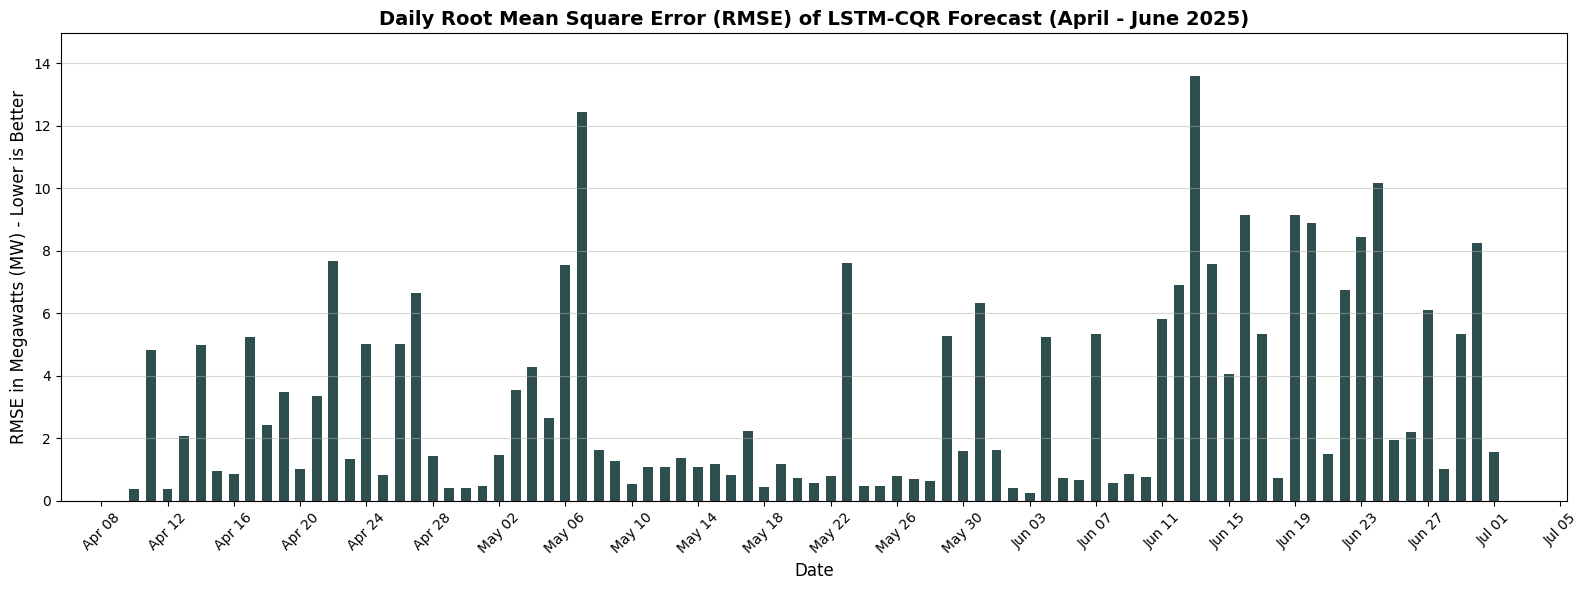

SUCCESS! Daily RMSE bar chart saved.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Generating Daily RMSE Bar Chart for Agus 2...")

# 1. Load the Validated CQR Results from Phase 3
df_cqr = pd.read_csv('Agus2_Validated_CQR_Results.csv', index_col='Time', parse_dates=True, dayfirst=True)

# 1A. Explicitly force the index to be datetime objects
df_cqr.index = pd.to_datetime(df_cqr.index, format='mixed', dayfirst=True)

# Note: We no longer need to exclude June 7! RMSE does not divide by actuals, 
# so 0 MW generation will not cause a mathematical singularity.

# 2. Calculate the Squared Error for every 15-minute step
squared_errors = (df_cqr['Actual_MW'] - df_cqr['Point_Prediction_MW']) ** 2

# 3. Aggregate into Daily Average (MSE), then take the square root for RMSE
daily_mse = squared_errors.resample('D').mean()
daily_rmse = np.sqrt(daily_mse)

# Clean up any purely blank days left behind
daily_rmse = daily_rmse.dropna()

# 4. Create the Bar Chart Visualization
plt.figure(figsize=(16, 6))

# Plotting the bars
plt.bar(daily_rmse.index, daily_rmse.values, color='#2F4F4F', width=0.6)

# 5. Professional Academic Formatting
plt.title('Daily Root Mean Square Error (RMSE) of LSTM-CQR Forecast (April - June 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('RMSE in Megawatts (MW) - Lower is Better', fontsize=12)

# Format x-axis to show the days neatly
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=4))
plt.xticks(rotation=45)

# Set y-axis limits to start exactly at 0, scaled slightly above the max bar
plt.ylim(0, daily_rmse.max() * 1.1)
plt.grid(axis='y', linestyle='-', alpha=0.5)

plt.tight_layout()

# Save and Show
plt.savefig('Agus2_Daily_RMSE.png', dpi=300, bbox_inches='tight')
plt.show()

print("SUCCESS! Daily RMSE bar chart saved.")

Generating Daily Winkler Penalty Tracker for Agus 2...


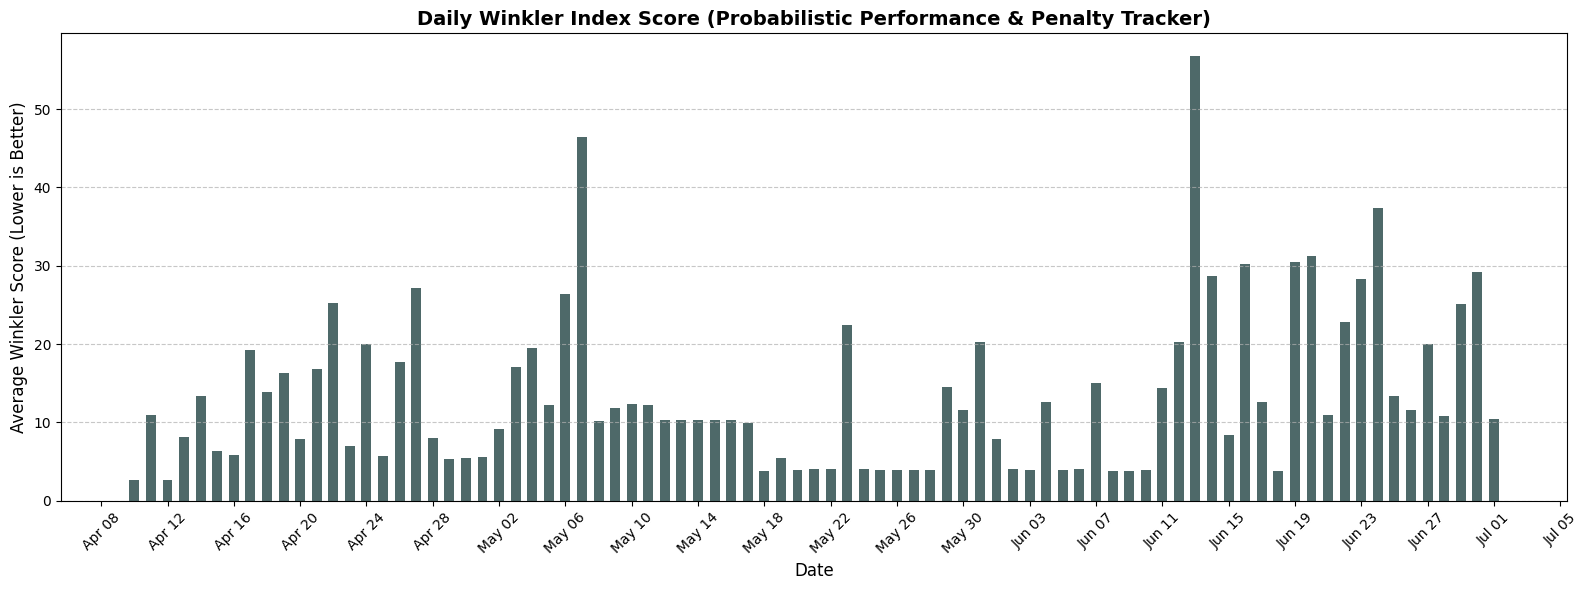

SUCCESS! Daily Winkler plot saved.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Generating Daily Winkler Penalty Tracker for Agus 2...")

# 1. Load the Validated CQR Results
df_cqr = pd.read_csv('Agus2_Validated_CQR_Results.csv', index_col='Time', parse_dates=True)

# Define your significance level
alpha = 0.10  

# 2. Mathematically Calculate the Winkler Score for EVERY 15-min interval
# Base interval width
df_cqr['Interval_Width'] = df_cqr['Physics_Upper_MW'] - df_cqr['Physics_Lower_MW']

# Initialize the Winkler score with the base width
df_cqr['Winkler_Score'] = df_cqr['Interval_Width']

# Apply the Severe Penalty if Actual drops BELOW the Lower Bound
penalty_low_mask = df_cqr['Actual_MW'] < df_cqr['Physics_Lower_MW']
df_cqr.loc[penalty_low_mask, 'Winkler_Score'] += (2 / alpha) * (df_cqr.loc[penalty_low_mask, 'Physics_Lower_MW'] - df_cqr.loc[penalty_low_mask, 'Actual_MW'])

# Apply the Severe Penalty if Actual spikes ABOVE the Upper Bound
penalty_high_mask = df_cqr['Actual_MW'] > df_cqr['Physics_Upper_MW']
df_cqr.loc[penalty_high_mask, 'Winkler_Score'] += (2 / alpha) * (df_cqr.loc[penalty_high_mask, 'Actual_MW'] - df_cqr.loc[penalty_high_mask, 'Physics_Upper_MW'])

# 3. Aggregate into Daily Average Winkler Scores
daily_winkler = df_cqr['Winkler_Score'].resample('D').mean().dropna()

# 4. Create the Visualization
plt.figure(figsize=(16, 6))

# Plotting the bars (Using a deep red/maroon to signify 'Penalties' and 'Uncertainty')
plt.bar(daily_winkler.index, daily_winkler.values, color='#2F4F4F', width=0.6, alpha=0.85)

# 5. Professional Academic Formatting
plt.title('Daily Winkler Index Score (Probabilistic Performance & Penalty Tracker)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Winkler Score (Lower is Better)', fontsize=12)

# Format x-axis to show the days neatly
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=4))
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save and Show
plt.savefig('Agus2_Daily_Winkler_Score.png', dpi=300, bbox_inches='tight')
plt.show()

print("SUCCESS! Daily Winkler plot saved.")